In [18]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 사전에 정의된 모델 임포트 (경로는 실제 환경에 맞게 수정)
from models import DynamicPacketGRU

# ---------------------------------------------------------
# 1. 평가용 Dataset 및 Collate 함수
# ---------------------------------------------------------
class TestPacketDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        x = torch.tensor(item["x"], dtype=torch.float32)
        label = item["label"]
        flow_size = item["flow_size_bytes"]
        return x, label, flow_size

def collate_fn_test(batch):
    xs = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.float32)
    flow_sizes = torch.tensor([item[2] for item in batch], dtype=torch.float32)
    return xs, labels, flow_sizes

def load_test_data(file_path):
    all_data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            all_data.append(json.loads(line))
    return all_data

# ---------------------------------------------------------
# 2. 모델 평가, 시간 및 패킷 확인 수 측정 함수
# ---------------------------------------------------------
def evaluate_model(model, test_loader, device, threshold=0.5, enable_early_exit=True, tolerance=0.05):
    model.eval()
    
    inference_times = []
    all_preds = []
    all_probs = []
    all_labels = []
    all_flow_sizes = []
    packets_checked_counts = []  # 각 데이터별 실제 확인한 패킷 수 저장 리스트
    
    print(f"추론을 시작합니다... (Early Exit: {enable_early_exit}, Tolerance: {tolerance})")
    
    with torch.no_grad():
        for x_batch, label_batch, flow_size_batch in test_loader:
            x_batch = x_batch.to(device)
            batch_size = x_batch.size(0)
            direction_idx = torch.ones(batch_size, dtype=torch.long).to(device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 시작
            start_time = time.perf_counter()
            
            # [수정] Early Exit 여부에 따른 모델 출력 파싱
            if enable_early_exit and batch_size == 1:
                # Early Exit 활성화 시 모델은 (최종 확률, 확인한 패킷 수)를 반환함
                final_prob, packets_seen = model(
                    x_batch, direction_idx=direction_idx, 
                    enable_early_exit=True, tolerance=tolerance
                )
                packets_checked_counts.append(packets_seen)
            else:
                # Early Exit 비활성화 시 일반 텐서 반환
                outputs = model(x_batch, direction_idx=direction_idx, enable_early_exit=False)
                final_prob = outputs[:, -1, :].squeeze(-1).cpu().item()
                packets_checked_counts.append(x_batch.size(1)) # 전체 시퀀스 길이 저장
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 종료
            end_time = time.perf_counter()
            inference_times.append(end_time - start_time)
            
            # 임계값 기준 분류
            predicted_label = 1 if final_prob >= threshold else 0
            
            all_probs.append(final_prob)
            all_preds.append(predicted_label)
            all_labels.extend(label_batch.numpy())
            all_flow_sizes.extend(flow_size_batch.numpy())

    return inference_times, all_probs, all_preds, all_labels, all_flow_sizes, packets_checked_counts

# ---------------------------------------------------------
# 3. 메인 실행 블록
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 설정할 파라미터
    seq_len = 5  # 테스트할 원본 시퀀스 길이 (최대 패킷 수)
    seq_num = 10
    dataset_type = "dctcp"
    threshold = 0.75
    
    # Early Exit 관련 설정
    enable_early_exit = True
    tolerance = 0.01
    
    # 경로 설정
    test_data_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_len}/test.jsonl"
    weight_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_num}/weights.pt"
    
    # 1) 데이터 로드 (추론 시간 및 조기 종료 개수 측정을 위해 batch_size=1 필수가 가깝습니다)
    test_list = load_test_data(test_data_path)
    test_dataset = TestPacketDataset(test_list)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn_test)
    
    # 2) 모델 초기화 및 가중치 로드
    model = DynamicPacketGRU(input_size=18, hidden_size=64).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"가중치 로드 완료: {weight_path}")
    
    # 3) 평가 수행 (packets_counts 추가 반환)
    times, probs, preds, labels, flow_sizes, packets_counts = evaluate_model(
        model, test_loader, device, threshold, enable_early_exit, tolerance
    )
    
    # 4) 추론 시간 계산 (단위: 밀리초 ms)
    times_ms = np.array(times) * 1000
    print("\n=== [1] 추론 시간 분석 (Inference Time) ===")
    print(f"최대 추론 시간 : {np.max(times_ms):.4f} ms")
    print(f"최소 추론 시간 : {np.min(times_ms):.4f} ms")
    print(f"평균 추론 시간 : {np.mean(times_ms):.4f} ms")
    
    # 5) [추가] 조기 종료 효율성 분석
    print("\n=== [2] 조기 종료 분석 (Early Exit Efficiency) ===")
    print(f"최대 허용 패킷 수 : {seq_len} 개")
    print(f"평균 확인 패킷 수 : {np.mean(packets_counts):.2f} 개")
    print(f"최소 확인 패킷 수 : {np.min(packets_counts)} 개")
    
    # 6) 분류 성능 지표 계산
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, zero_division=0)
    rec = recall_score(labels, preds, zero_division=0)
    f1 = f1_score(labels, preds, zero_division=0)
    
    print("\n=== [3] 분류 성능 지표 (Classification Metrics) ===")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    # 7) 데이터 정규화 및 산점도 시각화
    print("\n=== [4] 산점도 시각화 생성 중... ===")
    flow_sizes = np.array(flow_sizes)
    labels = np.array(labels)
    probs = np.array(probs)
    
    min_fs, max_fs = np.min(flow_sizes), np.max(flow_sizes)
    norm_flow_sizes = (flow_sizes - min_fs) / (max_fs - min_fs) if max_fs > min_fs else np.zeros_like(flow_sizes)
    
    plt.figure(figsize=(10, 6))
    idx_label_0 = (labels == 0)
    idx_label_1 = (labels == 1)
    
    plt.scatter(norm_flow_sizes[idx_label_0], probs[idx_label_0], color='blue', alpha=0.5, label='Actual Label 0', edgecolors='w', s=50)
    plt.scatter(norm_flow_sizes[idx_label_1], probs[idx_label_1], color='red', alpha=0.5, label='Actual Label 1', edgecolors='w', s=50)
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    
    plt.title(f"Predicted Probability vs Normalized Flow Size (Early Exit Avg Packets: {np.mean(packets_counts):.2f})")
    plt.xlabel("Normalized Flow Size Bytes (0 to 1)")
    plt.ylabel("Predicted Probability (0 to 1)")
    plt.ylim(-0.05, 1.05)
    plt.xlim(-0.05, 1.05)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
    plt.savefig(f'scatter_plot_seq{seq_len}_early_exit.png', dpi=300)
    plt.show()
    print(f"산점도가 'scatter_plot_seq{seq_len}_early_exit.png'로 저장되었습니다.")

가중치 로드 완료: dataset/elephant_dst_to_src/dctcp/seq10/weights.pt
추론을 시작합니다... (Early Exit: True, Tolerance: 0.01)

=== [1] 추론 시간 분석 (Inference Time) ===
최대 추론 시간 : 1.8429 ms
최소 추론 시간 : 0.1662 ms
평균 추론 시간 : 0.2175 ms

=== [2] 조기 종료 분석 (Early Exit Efficiency) ===
최대 허용 패킷 수 : 5 개
평균 확인 패킷 수 : 3.01 개
최소 확인 패킷 수 : 3 개


ValueError: Classification metrics can't handle a mix of continuous and binary targets

가중치 로드 완료: dataset/elephant_dst_to_src/dctcp/seq10/weights.pt
추론을 시작합니다... (Early Exit: True, Tolerance: 0.01)

=== [1] 추론 시간 분석 (Inference Time) ===
최대 추론 시간 : 0.6308 ms
최소 추론 시간 : 0.1242 ms
평균 추론 시간 : 0.2151 ms

=== [2] 조기 종료 분석 (Early Exit Efficiency) ===
최대 허용 패킷 수 : 3 개
평균 확인 패킷 수 : 2.98 개
최소 확인 패킷 수 : 2 개

=== [3] 분류 성능 지표 (Classification Metrics) ===
임계값(Threshold): 0.75
Accuracy  : 0.7700
Precision : 0.0000
Recall    : 0.0000
F1 Score  : 0.0000

=== [4] 산점도 시각화 생성 중... ===


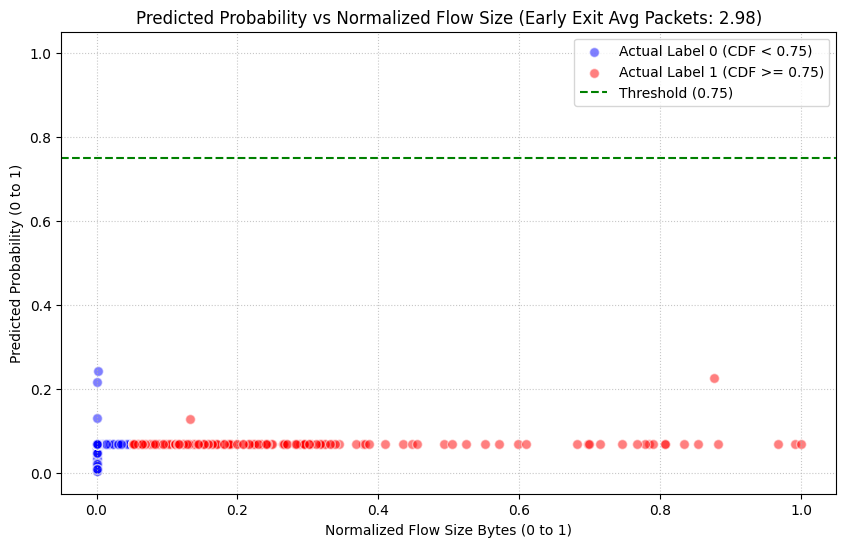

산점도가 'scatter_plot_seq3_early_exit.png'로 저장되었습니다.


In [22]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 사전에 정의된 모델 임포트 (경로는 실제 환경에 맞게 수정)
from models import DynamicPacketGRU

# ---------------------------------------------------------
# 1. 평가용 Dataset 및 Collate 함수
# ---------------------------------------------------------
class TestPacketDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        x = torch.tensor(item["x"], dtype=torch.float32)
        label = item["label"]
        flow_size = item["flow_size_bytes"]
        return x, label, flow_size

def collate_fn_test(batch):
    xs = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.float32)
    flow_sizes = torch.tensor([item[2] for item in batch], dtype=torch.float32)
    return xs, labels, flow_sizes

def load_test_data(file_path):
    all_data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            all_data.append(json.loads(line))
    return all_data

# ---------------------------------------------------------
# 2. 모델 평가, 시간 및 패킷 확인 수 측정 함수
# ---------------------------------------------------------
def evaluate_model(model, test_loader, device, threshold=0.5, enable_early_exit=True, tolerance=0.05):
    model.eval()
    
    inference_times = []
    all_preds = []
    all_probs = []
    all_labels = []
    all_flow_sizes = []
    packets_checked_counts = []  # 각 데이터별 실제 확인한 패킷 수 저장 리스트
    
    print(f"추론을 시작합니다... (Early Exit: {enable_early_exit}, Tolerance: {tolerance})")
    
    with torch.no_grad():
        for x_batch, label_batch, flow_size_batch in test_loader:
            x_batch = x_batch.to(device)
            batch_size = x_batch.size(0)
            direction_idx = torch.ones(batch_size, dtype=torch.long).to(device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 시작
            start_time = time.perf_counter()
            
            # Early Exit 여부에 따른 모델 출력 파싱
            if enable_early_exit and batch_size == 1:
                final_prob, packets_seen = model(
                    x_batch, direction_idx=direction_idx, 
                    enable_early_exit=True, tolerance=tolerance
                )
                packets_checked_counts.append(packets_seen)
            else:
                outputs = model(x_batch, direction_idx=direction_idx, enable_early_exit=False)
                final_prob = outputs[:, -1, :].squeeze(-1).cpu().item()
                packets_checked_counts.append(x_batch.size(1)) # 전체 시퀀스 길이 저장
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 종료
            end_time = time.perf_counter()
            inference_times.append(end_time - start_time)
            
            # 임계값 기준 분류
            predicted_label = 1 if final_prob >= threshold else 0
            
            all_probs.append(final_prob)
            all_preds.append(predicted_label)
            all_labels.extend(label_batch.numpy())
            all_flow_sizes.extend(flow_size_batch.numpy())

    return inference_times, all_probs, all_preds, all_labels, all_flow_sizes, packets_checked_counts

# ---------------------------------------------------------
# 3. 메인 실행 블록
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 설정할 파라미터
    seq_len = 3  # 테스트할 원본 시퀀스 길이 (최대 패킷 수)
    seq_num = 10
    dataset_type = "dctcp"
    threshold = 0.75
    
    # Early Exit 관련 설정
    enable_early_exit = True
    tolerance = 0.01
    
    # 경로 설정
    test_data_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_len}/test.jsonl"
    weight_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_num}/weights.pt"
    
    # 1) 데이터 로드
    test_list = load_test_data(test_data_path)
    test_dataset = TestPacketDataset(test_list)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn_test)
    
    # 2) 모델 초기화 및 가중치 로드
    model = DynamicPacketGRU(input_size=18, hidden_size=64).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"가중치 로드 완료: {weight_path}")
    
    # 3) 평가 수행
    times, probs, preds, labels, flow_sizes, packets_counts = evaluate_model(
        model, test_loader, device, threshold, enable_early_exit, tolerance
    )
    
    # 4) 추론 시간 계산 (단위: 밀리초 ms)
    times_ms = np.array(times) * 1000
    print("\n=== [1] 추론 시간 분석 (Inference Time) ===")
    print(f"최대 추론 시간 : {np.max(times_ms):.4f} ms")
    print(f"최소 추론 시간 : {np.min(times_ms):.4f} ms")
    print(f"평균 추론 시간 : {np.mean(times_ms):.4f} ms")
    
    # 5) 조기 종료 효율성 분석
    print("\n=== [2] 조기 종료 분석 (Early Exit Efficiency) ===")
    print(f"최대 허용 패킷 수 : {seq_len} 개")
    print(f"평균 확인 패킷 수 : {np.mean(packets_counts):.2f} 개")
    print(f"최소 확인 패킷 수 : {np.min(packets_counts)} 개")
    
    # 6) [수정] 분류 성능 지표 계산
    # 0~1 사이의 CDF 라벨을 threshold 기준으로 0과 1로 이진화합니다.
    binary_labels = (np.array(labels) >= threshold).astype(int)
    
    acc = accuracy_score(binary_labels, preds)
    prec = precision_score(binary_labels, preds, zero_division=0)
    rec = recall_score(binary_labels, preds, zero_division=0)
    f1 = f1_score(binary_labels, preds, zero_division=0)
    
    print("\n=== [3] 분류 성능 지표 (Classification Metrics) ===")
    print(f"임계값(Threshold): {threshold}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    # 7) [수정] 데이터 정규화 및 산점도 시각화
    print("\n=== [4] 산점도 시각화 생성 중... ===")
    flow_sizes = np.array(flow_sizes)
    probs = np.array(probs)
    
    min_fs, max_fs = np.min(flow_sizes), np.max(flow_sizes)
    norm_flow_sizes = (flow_sizes - min_fs) / (max_fs - min_fs) if max_fs > min_fs else np.zeros_like(flow_sizes)
    
    plt.figure(figsize=(10, 6))
    
    # 시각화 그룹 분기 시에도 이진화된 라벨(binary_labels)을 사용합니다.
    idx_label_0 = (binary_labels == 0)
    idx_label_1 = (binary_labels == 1)
    
    plt.scatter(norm_flow_sizes[idx_label_0], probs[idx_label_0], color='blue', alpha=0.5, label=f'Actual Label 0 (CDF < {threshold})', edgecolors='w', s=50)
    plt.scatter(norm_flow_sizes[idx_label_1], probs[idx_label_1], color='red', alpha=0.5, label=f'Actual Label 1 (CDF >= {threshold})', edgecolors='w', s=50)
    plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
    
    plt.title(f"Predicted Probability vs Normalized Flow Size (Early Exit Avg Packets: {np.mean(packets_counts):.2f})")
    plt.xlabel("Normalized Flow Size Bytes (0 to 1)")
    plt.ylabel("Predicted Probability (0 to 1)")
    plt.ylim(-0.05, 1.05)
    plt.xlim(-0.05, 1.05)
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.7)
    
   # plt.savefig(f'scatter_plot_seq{seq_len}_early_exit.png', dpi=300)
    plt.show()
    print(f"산점도가 'scatter_plot_seq{seq_len}_early_exit.png'로 저장되었습니다.")

가중치 로드 완료: dataset/elephant_dst_to_src/fb/seq10/weights.pt
추론을 시작합니다... (Early Exit: True, Tolerance: 0.01)

=== [1] 추론 시간 분석 (Inference Time) ===
최대 추론 시간 : 0.5399 ms
최소 추론 시간 : 0.1291 ms
평균 추론 시간 : 0.2102 ms

=== [2] 조기 종료 분석 (Early Exit Efficiency) ===
최대 허용 패킷 수 : 3 개
평균 확인 패킷 수 : 3.00 개
최소 확인 패킷 수 : 2 개

=== [3] 분류 성능 지표 (Classification Metrics) ===
임계값(Threshold): 0.75
Accuracy  : 0.9630
Precision : 0.8811
Recall    : 0.9882
F1 Score  : 0.9316

=== [4] 산점도 시각화 생성 중... ===


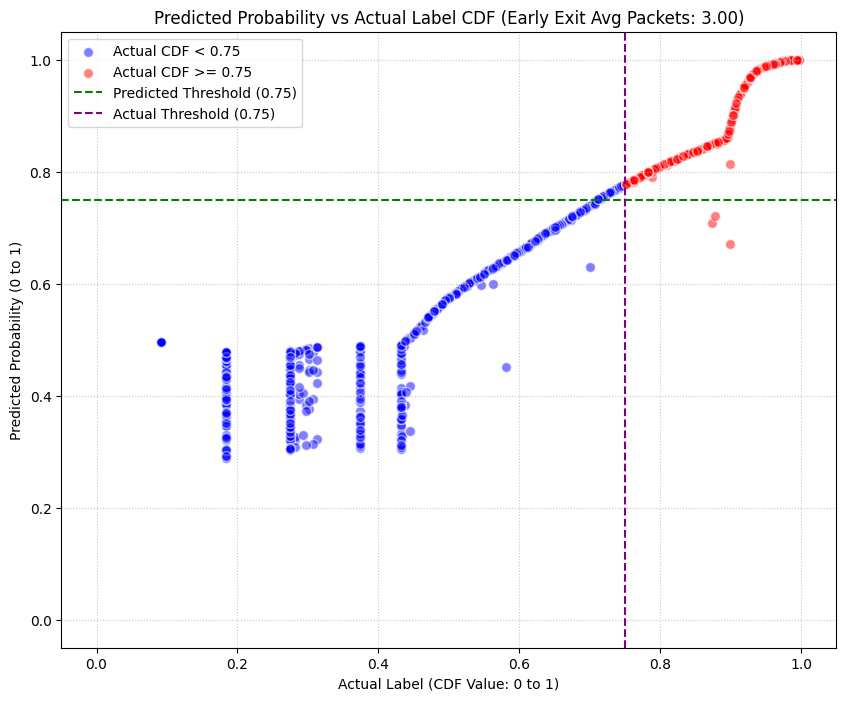

산점도 출력이 완료되었습니다.


In [ ]:
import json
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 사전에 정의된 모델 임포트 (경로는 실제 환경에 맞게 수정)
from models import DynamicPacketGRU

# ---------------------------------------------------------
# 1. 평가용 Dataset 및 Collate 함수
# ---------------------------------------------------------
class TestPacketDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        x = torch.tensor(item["x"], dtype=torch.float32)
        label = item["label"]
        flow_size = item["flow_size_bytes"]
        return x, label, flow_size

def collate_fn_test(batch):
    xs = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.float32)
    flow_sizes = torch.tensor([item[2] for item in batch], dtype=torch.float32)
    return xs, labels, flow_sizes

def load_test_data(file_path):
    all_data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            all_data.append(json.loads(line))
    return all_data

# ---------------------------------------------------------
# 2. 모델 평가, 시간 및 패킷 확인 수 측정 함수
# ---------------------------------------------------------
def evaluate_model(model, test_loader, device, threshold=0.5, enable_early_exit=True, tolerance=0.05):
    model.eval()
    
    inference_times = []
    all_preds = []
    all_probs = []
    all_labels = []
    all_flow_sizes = []
    packets_checked_counts = []  # 각 데이터별 실제 확인한 패킷 수 저장 리스트
    
    print(f"추론을 시작합니다... (Early Exit: {enable_early_exit}, Tolerance: {tolerance})")
    
    with torch.no_grad():
        for x_batch, label_batch, flow_size_batch in test_loader:
            x_batch = x_batch.to(device)
            batch_size = x_batch.size(0)
            direction_idx = torch.ones(batch_size, dtype=torch.long).to(device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 시작
            start_time = time.perf_counter()
            
            # Early Exit 여부에 따른 모델 출력 파싱
            if enable_early_exit and batch_size == 1:
                final_prob, packets_seen = model(
                    x_batch, direction_idx=direction_idx, 
                    enable_early_exit=True, tolerance=tolerance
                )
                packets_checked_counts.append(packets_seen)
            else:
                outputs = model(x_batch, direction_idx=direction_idx, enable_early_exit=False)
                final_prob = outputs[:, -1, :].squeeze(-1).cpu().item()
                packets_checked_counts.append(x_batch.size(1)) # 전체 시퀀스 길이 저장
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 종료
            end_time = time.perf_counter()
            inference_times.append(end_time - start_time)
            
            # 임계값 기준 분류
            predicted_label = 1 if final_prob >= threshold else 0
            
            all_probs.append(final_prob)
            all_preds.append(predicted_label)
            all_labels.extend(label_batch.numpy())
            all_flow_sizes.extend(flow_size_batch.numpy())

    return inference_times, all_probs, all_preds, all_labels, all_flow_sizes, packets_checked_counts

# ---------------------------------------------------------
# 3. 메인 실행 블록
# ---------------------------------------------------------
if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # 설정할 파라미터
    seq_len = 10  # 테스트할 원본 시퀀스 길이 (최대 패킷 수)
    seq_num = 10
    dataset_type = "fb"
    threshold = 0.75
    
    # Early Exit 관련 설정
    enable_early_exit = True
    tolerance = 0.01
    
    # 경로 설정
    test_data_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_len}/test.jsonl"
    weight_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_num}/weights.pt"
    
    # 1) 데이터 로드
    test_list = load_test_data(test_data_path)
    test_dataset = TestPacketDataset(test_list)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn_test)
    
    # 2) 모델 초기화 및 가중치 로드
    model = DynamicPacketGRU(input_size=18, hidden_size=64).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"가중치 로드 완료: {weight_path}")
    
    # 3) 평가 수행
    times, probs, preds, labels, flow_sizes, packets_counts = evaluate_model(
        model, test_loader, device, threshold, enable_early_exit, tolerance
    )
    
    # 4) 추론 시간 계산 (단위: 밀리초 ms)
    times_ms = np.array(times) * 1000
    print("\n=== [1] 추론 시간 분석 (Inference Time) ===")
    print(f"최대 추론 시간 : {np.max(times_ms):.4f} ms")
    print(f"최소 추론 시간 : {np.min(times_ms):.4f} ms")
    print(f"평균 추론 시간 : {np.mean(times_ms):.4f} ms")
    
    # 5) 조기 종료 효율성 분석
    print("\n=== [2] 조기 종료 분석 (Early Exit Efficiency) ===")
    print(f"최대 허용 패킷 수 : {seq_len} 개")
    print(f"평균 확인 패킷 수 : {np.mean(packets_counts):.2f} 개")
    print(f"최소 확인 패킷 수 : {np.min(packets_counts)} 개")
    
    # 6) 분류 성능 지표 계산
    binary_labels = (np.array(labels) >= threshold).astype(int)
    
    acc = accuracy_score(binary_labels, preds)
    prec = precision_score(binary_labels, preds, zero_division=0)
    rec = recall_score(binary_labels, preds, zero_division=0)
    f1 = f1_score(binary_labels, preds, zero_division=0)
    
    print("\n=== [3] 분류 성능 지표 (Classification Metrics) ===")
    print(f"임계값(Threshold): {threshold}")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1 Score  : {f1:.4f}")
    
    # 7) [수정] 산점도 시각화 (x축: 실제 라벨 CDF, y축: 예측 확률)
    print("\n=== [4] 산점도 시각화 생성 중... ===")
    labels = np.array(labels)
    probs = np.array(probs)
    
    plt.figure(figsize=(10, 8))
    
    # 실제 라벨(CDF)이 threshold 기준 좌측(0)인지 우측(1)인지에 따라 색상 분기
    idx_label_0 = (binary_labels == 0)
    idx_label_1 = (binary_labels == 1)
    
    # x축을 실제 라벨(labels)로 변경
    plt.scatter(labels[idx_label_0], probs[idx_label_0], color='blue', alpha=0.5, label=f'Actual CDF < {threshold}', edgecolors='w', s=50)
    plt.scatter(labels[idx_label_1], probs[idx_label_1], color='red', alpha=0.5, label=f'Actual CDF >= {threshold}', edgecolors='w', s=50)
    
    # 수평선 (y = threshold): 예측값 기준선 (X축과 평행)
    plt.axhline(y=threshold, color='green', linestyle='--', linewidth=1.5, label=f'Predicted Threshold ({threshold})')
    # 수직선 (x = threshold): 실제 라벨 기준선 (Y축과 평행)
    plt.axvline(x=threshold, color='purple', linestyle='--', linewidth=1.5, label=f'Actual Threshold ({threshold})')
    
    plt.title(f"Predicted Probability vs Actual Label CDF (Early Exit Avg Packets: {np.mean(packets_counts):.2f})")
    plt.xlabel("Actual Label (CDF Value: 0 to 1)")
    plt.ylabel("Predicted Probability (0 to 1)")
    plt.ylim(-0.05, 1.05)
    plt.xlim(-0.05, 1.05)
    plt.legend(loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.7)
    
    # plt.savefig(f'scatter_plot_seq{seq_len}_early_exit.png', dpi=300)
    plt.show()
    print(f"산점도 출력이 완료되었습니다.")

In [3]:
import json

✅ 모델 준비 완료 (학습 분포: univ1, 테스트 분포: vl2)
추론을 시작합니다... (Early Exit: True, Tolerance: 0.01)

=== [1] 분포 편향(Dataset Shift) 평가 지표 ===
Weight Threshold (Y축-예측 기준): 0.8100
Predict Threshold (X축-실제 기준): 0.7900
정확도(Accuracy)  : 0.9750  (975/1000)
정밀도(Precision) : 0.9004
재현율(Recall)    : 0.9905
F1-Score          : 0.9433

=== [2] 사분면 산점도 시각화 생성 중... ===


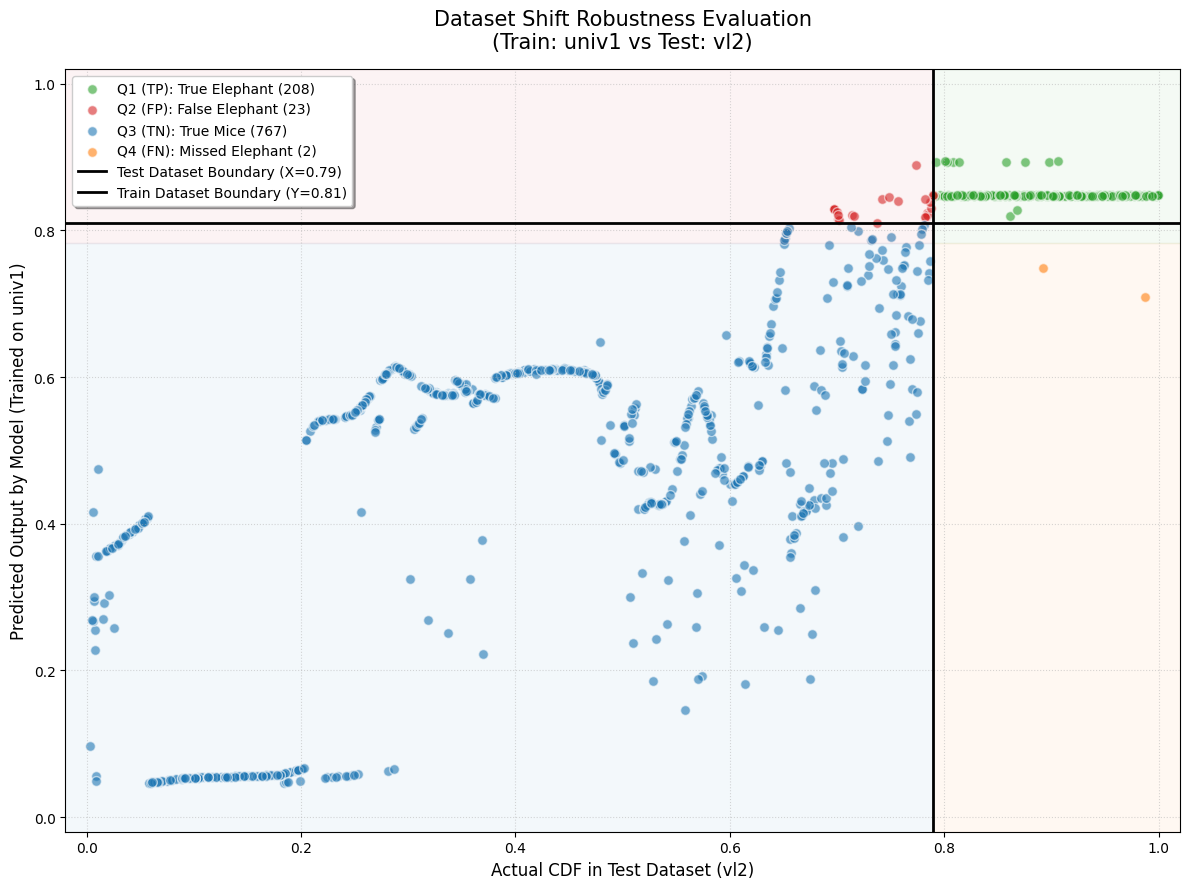

사분면 산점도 출력이 완료되었습니다.


In [6]:
import json

import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 사전에 정의된 모델 임포트 (경로는 실제 환경에 맞게 수정)
from models import DynamicPacketGRU, get_flow_stats

# ---------------------------------------------------------
# 1. 평가용 Dataset 및 Collate 함수
# ---------------------------------------------------------
class TestPacketDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        x = torch.tensor(item["x"], dtype=torch.float32)
        label = item["label"]
        flow_size = item["flow_size_bytes"]
        return x, label, flow_size

def collate_fn_test(batch):
    xs = torch.stack([item[0] for item in batch])
    labels = torch.tensor([item[1] for item in batch], dtype=torch.float32)
    flow_sizes = torch.tensor([item[2] for item in batch], dtype=torch.float32)
    return xs, labels, flow_sizes

def load_test_data(file_path):
    all_data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            all_data.append(json.loads(line))
    return all_data

# ---------------------------------------------------------
# 2. 모델 평가, 시간 및 패킷 확인 수 측정 함수
# ---------------------------------------------------------
def evaluate_model(model, test_loader, device, threshold=0.5, enable_early_exit=True, tolerance=0.05):
    model.eval()
    
    inference_times = []
    all_preds = []
    all_probs = []
    all_labels = []
    all_flow_sizes = []
    packets_checked_counts = []  # 각 데이터별 실제 확인한 패킷 수 저장 리스트
    
    print(f"추론을 시작합니다... (Early Exit: {enable_early_exit}, Tolerance: {tolerance})")
    
    with torch.no_grad():
        for x_batch, label_batch, flow_size_batch in test_loader:
            x_batch = x_batch.to(device)
            batch_size = x_batch.size(0)
            direction_idx = torch.ones(batch_size, dtype=torch.long).to(device)
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 시작
            start_time = time.perf_counter()
            
            # Early Exit 여부에 따른 모델 출력 파싱
            if enable_early_exit and batch_size == 1:
                final_prob, packets_seen = model(
                    x_batch, direction_idx=direction_idx, 
                    enable_early_exit=True, tolerance=tolerance
                )
                packets_checked_counts.append(packets_seen)
            else:
                outputs = model(x_batch, direction_idx=direction_idx, enable_early_exit=False)
                final_prob = outputs[:, -1, :].squeeze(-1).cpu().item()
                packets_checked_counts.append(x_batch.size(1)) # 전체 시퀀스 길이 저장
            
            if device.type == 'cuda':
                torch.cuda.synchronize()
            
            # 시간 측정 종료
            end_time = time.perf_counter()
            inference_times.append(end_time - start_time)
            
            # 임계값 기준 분류
            predicted_label = 1 if final_prob >= threshold else 0
            
            all_probs.append(final_prob)
            all_preds.append(predicted_label)
            all_labels.extend(label_batch.numpy())
            all_flow_sizes.extend(flow_size_batch.numpy())

    return inference_times, all_probs, all_preds, all_labels, all_flow_sizes, packets_checked_counts

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    seq_len = 10 
    weight_type = "univ1"
    dataset_type = "vl2" # 예시: 학습과 다른 데이터셋으로 설정
    threshold_size = 50000
    
    # 1. Threshold 및 정규화 통계량 추출
    weight_threshold, w_mean, w_var = get_flow_stats(
        f"dataset/elephant_dst_to_src/{weight_type}/seq10/dataset.jsonl", threshold_size
    )
    predict_threshold, p_mean, p_var = get_flow_stats(
        f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_len}/test.jsonl", threshold_size
    )
    
    # Early Exit 설정
    enable_early_exit = True
    tolerance = 0.01
    
    test_data_path = f"dataset/elephant_dst_to_src/{dataset_type}/seq{seq_len}/test.jsonl"
    weight_path = f"dataset/elephant_dst_to_src/{weight_type}/seq10/weights.pt"
    
    # 2. 데이터 로드 및 모델 초기화 (w_mean, w_var 사용)
    test_list = load_test_data(test_data_path)
    test_dataset = TestPacketDataset(test_list)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, collate_fn=collate_fn_test)
    
    model = DynamicPacketGRU(input_size=18, hidden_size=64).to(device)
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"✅ 모델 준비 완료 (학습 분포: {weight_type}, 테스트 분포: {dataset_type})")
    
    # 3. 모델 추론 (임의의 임계값 0.5를 주어 실행하되 판별은 아래에서 다시 수행)
    times, probs, preds, labels, flow_sizes, packets_counts = evaluate_model(
        model, test_loader, device, threshold=0.5, enable_early_exit=enable_early_exit, tolerance=tolerance
    )
    
    # Numpy 배열로 변환
    labels = np.array(labels)
    probs = np.array(probs)
    
    # ---------------------------------------------------------
    # 4. 사분면(Quadrant) 기반 OOD(Out-of-Distribution) 성능 평가
    # ---------------------------------------------------------
    # X축 (실제 라벨): 테스트 데이터셋의 임계값(predict_threshold) 기준
    true_classes = (labels >= predict_threshold).astype(int)
    
    # Y축 (예측 라벨): 학습 데이터셋의 임계값(weight_threshold) 기준
    pred_classes = (probs >= weight_threshold).astype(int)
    
    # 4개의 사분면(혼동 행렬) 마스크 생성
    idx_tp = (true_classes == 1) & (pred_classes == 1) # 1사분면: True Positive (우상단)
    idx_fp = (true_classes == 0) & (pred_classes == 1) # 2사분면: False Positive (좌상단)
    idx_tn = (true_classes == 0) & (pred_classes == 0) # 3사분면: True Negative (좌하단)
    idx_fn = (true_classes == 1) & (pred_classes == 0) # 4사분면: False Negative (우하단)
    
    # 지표 계산
    tp_cnt, fp_cnt, tn_cnt, fn_cnt = idx_tp.sum(), idx_fp.sum(), idx_tn.sum(), idx_fn.sum()
    total_cnt = len(labels)
    
    acc = (tp_cnt + tn_cnt) / total_cnt if total_cnt > 0 else 0
    prec = tp_cnt / (tp_cnt + fp_cnt) if (tp_cnt + fp_cnt) > 0 else 0
    rec = tp_cnt / (tp_cnt + fn_cnt) if (tp_cnt + fn_cnt) > 0 else 0
    f1 = 2 * (prec * rec) / (prec + rec) if (prec + rec) > 0 else 0
    
    print("\n=== [1] 분포 편향(Dataset Shift) 평가 지표 ===")
    print(f"Weight Threshold (Y축-예측 기준): {weight_threshold:.4f}")
    print(f"Predict Threshold (X축-실제 기준): {predict_threshold:.4f}")
    print(f"정확도(Accuracy)  : {acc:.4f}  ({tp_cnt+tn_cnt}/{total_cnt})")
    print(f"정밀도(Precision) : {prec:.4f}")
    print(f"재현율(Recall)    : {rec:.4f}")
    print(f"F1-Score          : {f1:.4f}")
    
    # ---------------------------------------------------------
    # 5. 사분면 산점도 시각화
    # ---------------------------------------------------------
    print("\n=== [2] 사분면 산점도 시각화 생성 중... ===")
    
    plt.figure(figsize=(12, 9))
    
    # 각 사분면별 산점도 그리기
    # 1사분면 (정답-코끼리 / 예측-코끼리)
    plt.scatter(labels[idx_tp], probs[idx_tp], color='#2ca02c', alpha=0.6, s=50, edgecolors='w',
                label=f'Q1 (TP): True Elephant ({tp_cnt})')
    # 2사분면 (정답-쥐 / 예측-코끼리) - 오분류
    plt.scatter(labels[idx_fp], probs[idx_fp], color='#d62728', alpha=0.6, s=50, edgecolors='w',
                label=f'Q2 (FP): False Elephant ({fp_cnt})')
    # 3사분면 (정답-쥐 / 예측-쥐)
    plt.scatter(labels[idx_tn], probs[idx_tn], color='#1f77b4', alpha=0.6, s=50, edgecolors='w',
                label=f'Q3 (TN): True Mice ({tn_cnt})')
    # 4사분면 (정답-코끼리 / 예측-쥐) - 오분류
    plt.scatter(labels[idx_fn], probs[idx_fn], color='#ff7f0e', alpha=0.6, s=50, edgecolors='w',
                label=f'Q4 (FN): Missed Elephant ({fn_cnt})')
    
    # 두 개의 임계값 선 그리기 (사분면을 가르는 기준)
    plt.axvline(x=predict_threshold, color='black', linestyle='-', linewidth=2, 
                label=f'Test Dataset Boundary (X={predict_threshold:.2f})')
    plt.axhline(y=weight_threshold, color='black', linestyle='-', linewidth=2, 
                label=f'Train Dataset Boundary (Y={weight_threshold:.2f})')
    
    # 배경색을 연하게 칠해 사분면 직관성 강화
    plt.axvspan(predict_threshold, 1.05, ymin=weight_threshold/1.05, ymax=1.0, color='#2ca02c', alpha=0.05) # 1사분면 (TP 구역)
    plt.axvspan(-0.05, predict_threshold, ymin=weight_threshold/1.05, ymax=1.0, color='#d62728', alpha=0.05) # 2사분면 (FP 구역)
    plt.axvspan(-0.05, predict_threshold, ymin=0, ymax=weight_threshold/1.05, color='#1f77b4', alpha=0.05) # 3사분면 (TN 구역)
    plt.axvspan(predict_threshold, 1.05, ymin=0, ymax=weight_threshold/1.05, color='#ff7f0e', alpha=0.05) # 4사분면 (FN 구역)
    
    plt.title(f"Dataset Shift Robustness Evaluation\n(Train: {weight_type} vs Test: {dataset_type})", fontsize=15, pad=15)
    plt.xlabel(f"Actual CDF in Test Dataset ({dataset_type})", fontsize=12)
    plt.ylabel(f"Predicted Output by Model (Trained on {weight_type})", fontsize=12)
    
    plt.xlim(-0.02, 1.02)
    plt.ylim(-0.02, 1.02)
    
    plt.legend(loc='upper left', frameon=True, shadow=True, fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    
    plt.tight_layout()
    plt.show()
    print("사분면 산점도 출력이 완료되었습니다.")